# Heart Failure — Kaplan-Meier Survival Analysis

This notebook performs Kaplan-Meier (KM) survival analysis on 299 heart-failure patients:
- Overall KM survival estimate
- KM curves stratified by each clinical feature
- Log-rank tests to compare survival curves
- Median survival times per subgroup

**Library:** `lifelines` (modern, actively maintained survival-analysis library)

In [2]:
!pip install -q lifelines pandas numpy matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

print('Libraries loaded ✔')

Libraries loaded ✔


## 1 · Load Data

In [4]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

# Duration & event columns
T = df['time']           # follow-up time in days
E = df['DEATH_EVENT']    # 1 = event (death), 0 = censored

print(f'Loaded {len(df)} patients | Events: {E.sum()} | Censored: {(E==0).sum()}')
df.head(3)

Loaded 299 patients | Events: 96 | Censored: 203


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1


## 2 · Overall Kaplan-Meier Curve

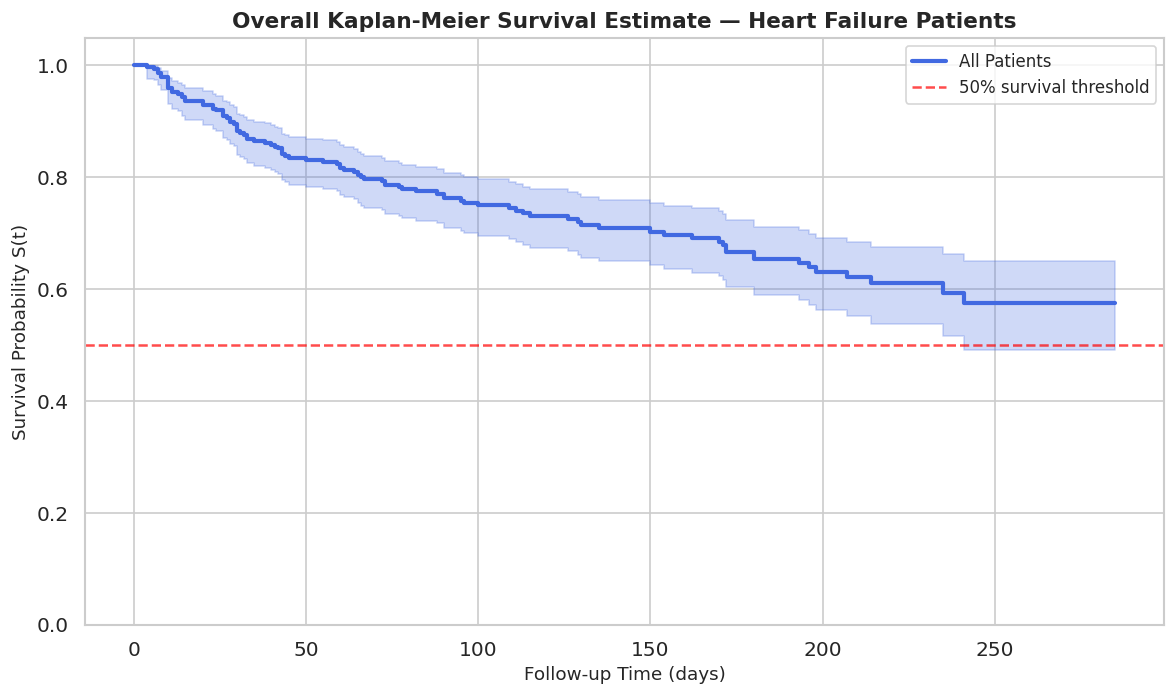

Median survival time: inf days
Survival at 100 days: 0.750
Survival at 200 days: 0.631


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='All Patients')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, color='royalblue',
                           linewidth=2.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='50% survival threshold')
ax.set_xlabel('Follow-up Time (days)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_title('Overall Kaplan-Meier Survival Estimate — Heart Failure Patients',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)

# Add median survival annotation
med = kmf.median_survival_time_
ax.annotate(f'Median survival: {med:.0f} days',
            xy=(med, 0.5), xytext=(med + 20, 0.58),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f'Median survival time: {med:.0f} days')
print(f'Survival at 100 days: {kmf.survival_function_at_times([100]).values[0]:.3f}')
print(f'Survival at 200 days: {kmf.survival_function_at_times([200]).values[0]:.3f}')

## 3 · KM Curves — Helper Function

In [6]:
def plot_km_by_feature(df, feature, labels, title, colors=None, ax=None):
    """Plot stratified KM curves with log-rank test p-value."""
    if colors is None:
        colors = ['royalblue', 'tomato', 'forestgreen', 'darkorchid']
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
        standalone = True
    else:
        standalone = False

    groups = sorted(df[feature].unique())
    durations_by_group = []
    events_by_group    = []

    for g, color in zip(groups, colors):
        mask = df[feature] == g
        kmf = KaplanMeierFitter()
        kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'DEATH_EVENT'],
                label=f'{labels[g]} (n={mask.sum()})')
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color,
                                   linewidth=2)
        durations_by_group.append(df.loc[mask, 'time'])
        events_by_group.append(df.loc[mask, 'DEATH_EVENT'])

    # Log-rank test
    if len(groups) == 2:
        result = logrank_test(durations_by_group[0], durations_by_group[1],
                              event_observed_A=events_by_group[0],
                              event_observed_B=events_by_group[1])
        p_val = result.p_value
    else:
        all_dur = pd.concat(durations_by_group)
        all_ev  = pd.concat(events_by_group)
        all_grp = pd.concat([pd.Series([g]*len(d))
                             for g, d in zip(groups, durations_by_group)])
        result = multivariate_logrank_test(all_dur, all_grp, all_ev)
        p_val = result.p_value

    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else
          ('*' if p_val < 0.05 else 'ns'))
    ax.set_title(f'{title}\nLog-rank p = {p_val:.4f} {sig}',
                 fontweight='bold')
    ax.set_xlabel('Follow-up Time (days)')
    ax.set_ylabel('Survival Probability S(t)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

    if standalone:
        plt.tight_layout()
        plt.show()
    return p_val

print('Helper function defined ✔')

Helper function defined ✔


## 4 · KM by Sex

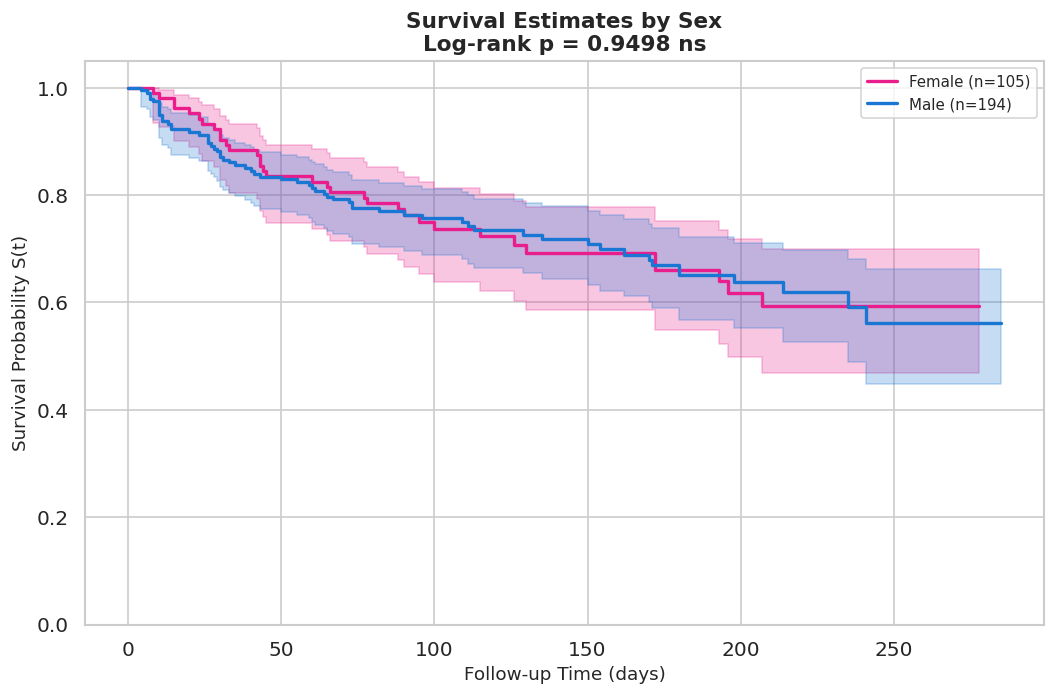

In [7]:
plot_km_by_feature(df, 'sex',
                   labels={0: 'Female', 1: 'Male'},
                   title='Survival Estimates by Sex',
                   colors=['#E91E8C', '#1976D2']);

## 5 · KM by Anaemia

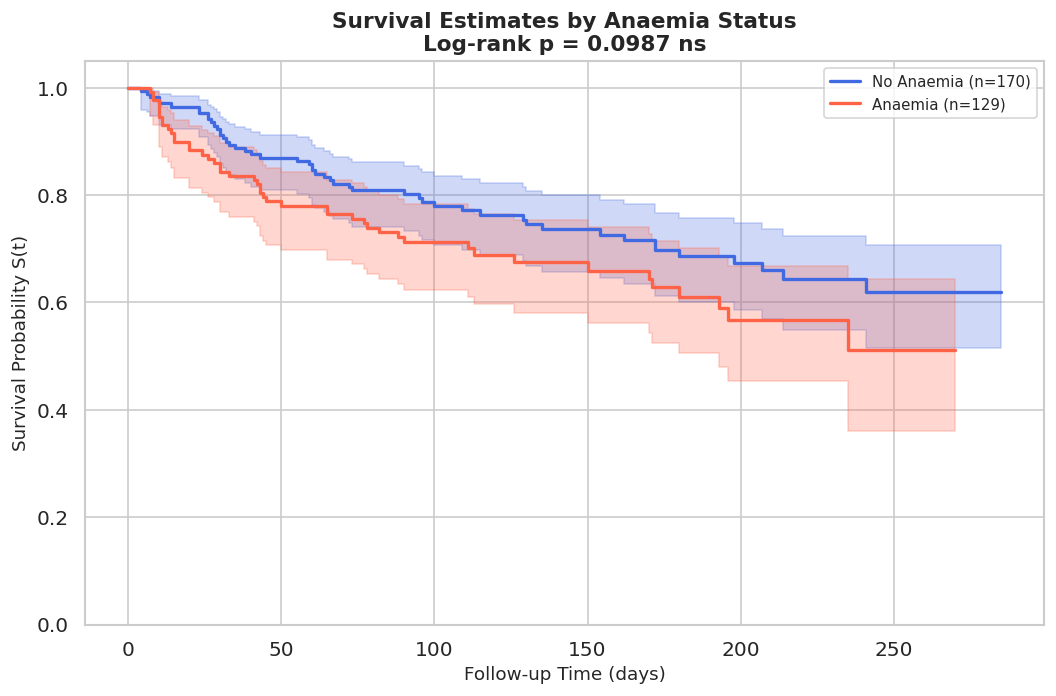

In [8]:
plot_km_by_feature(df, 'anaemia',
                   labels={0: 'No Anaemia', 1: 'Anaemia'},
                   title='Survival Estimates by Anaemia Status');

## 6 · KM by Diabetes

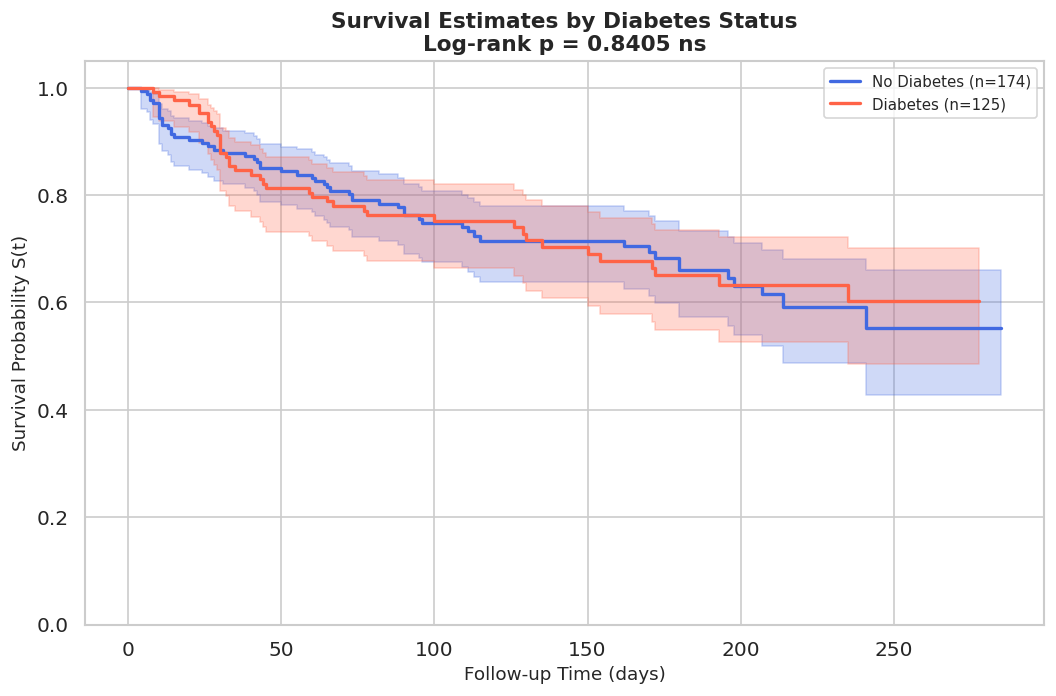

In [9]:
plot_km_by_feature(df, 'diabetes',
                   labels={0: 'No Diabetes', 1: 'Diabetes'},
                   title='Survival Estimates by Diabetes Status');

## 7 · KM by High Blood Pressure

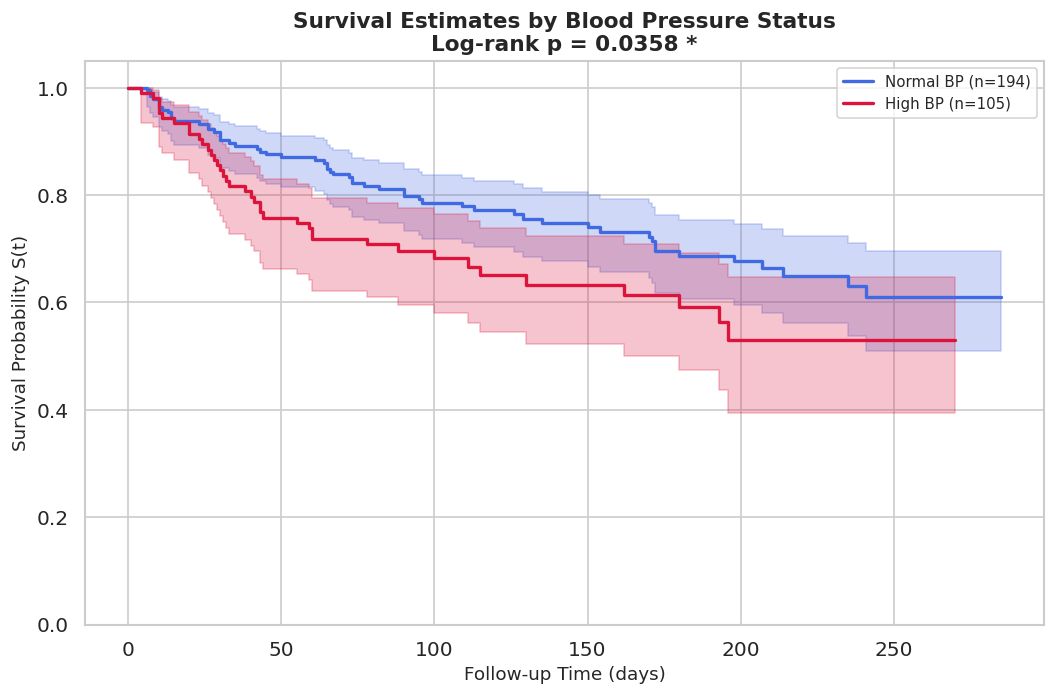

In [10]:
plot_km_by_feature(df, 'high_blood_pressure',
                   labels={0: 'Normal BP', 1: 'High BP'},
                   title='Survival Estimates by Blood Pressure Status',
                   colors=['royalblue', 'crimson']);

## 8 · KM by Smoking

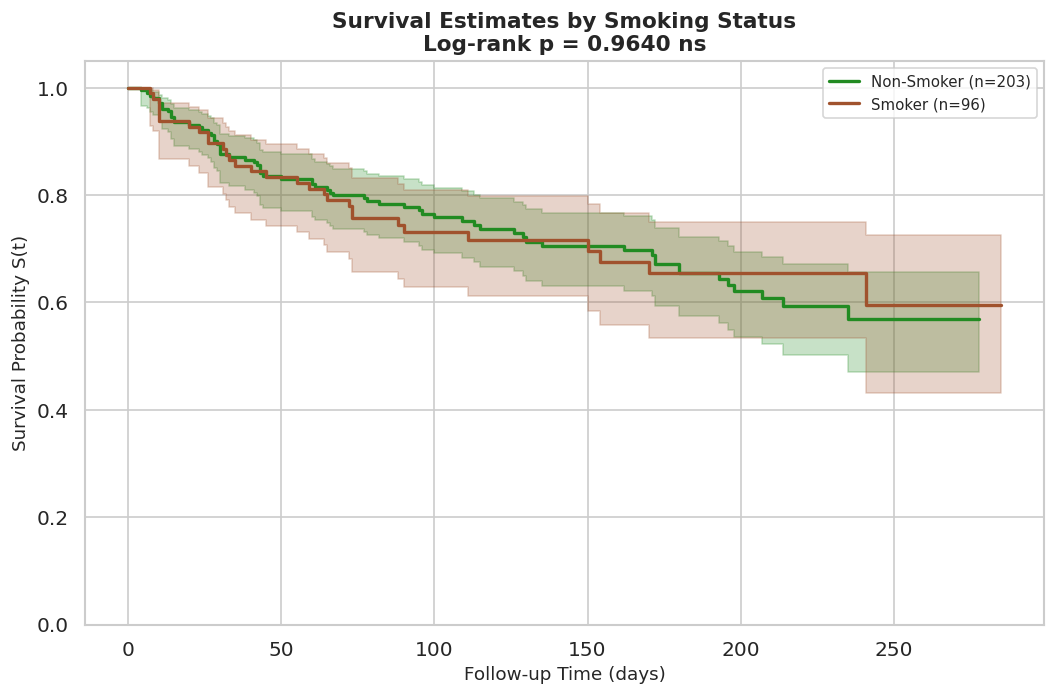

In [11]:
plot_km_by_feature(df, 'smoking',
                   labels={0: 'Non-Smoker', 1: 'Smoker'},
                   title='Survival Estimates by Smoking Status',
                   colors=['forestgreen', 'sienna']);

## 9 · KM by Ejection Fraction (Tertiles)

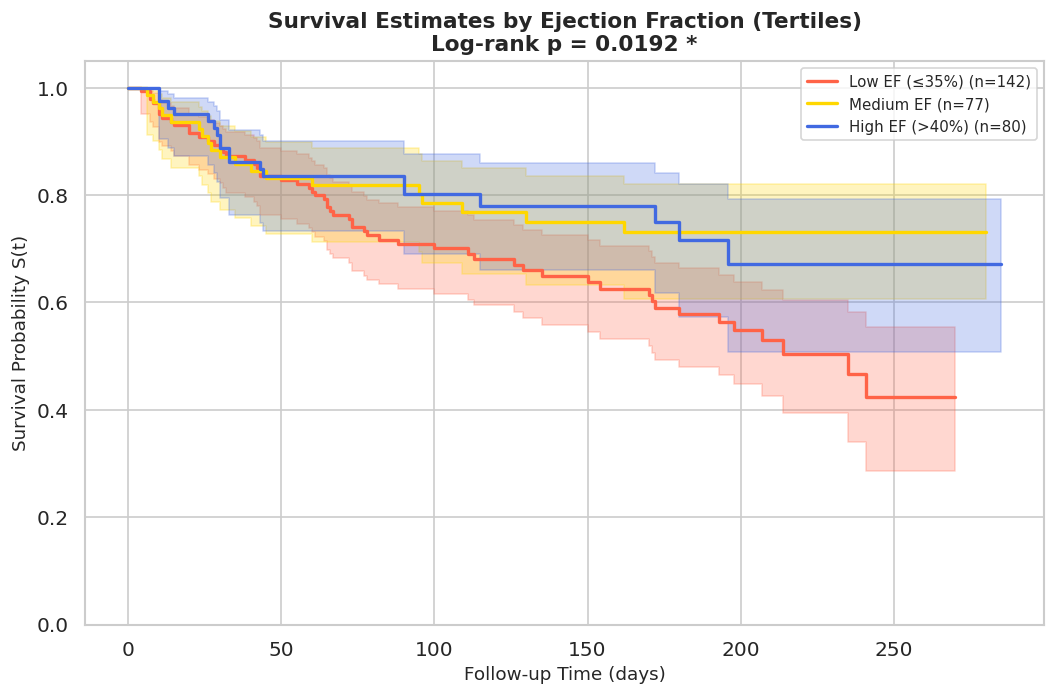

In [12]:
df['ef_group'] = pd.qcut(df['ejection_fraction'], q=3,
                          labels=['Low EF', 'Medium EF', 'High EF'])
df['ef_code'] = df['ef_group'].cat.codes  # 0, 1, 2

plot_km_by_feature(df, 'ef_code',
                   labels={0: f'Low EF (≤{df.ejection_fraction.quantile(0.33):.0f}%)',
                            1: 'Medium EF',
                            2: f'High EF (>{df.ejection_fraction.quantile(0.67):.0f}%)'},
                   title='Survival Estimates by Ejection Fraction (Tertiles)',
                   colors=['tomato', 'gold', 'royalblue']);

## 10 · KM by Serum Creatinine (Median Split)

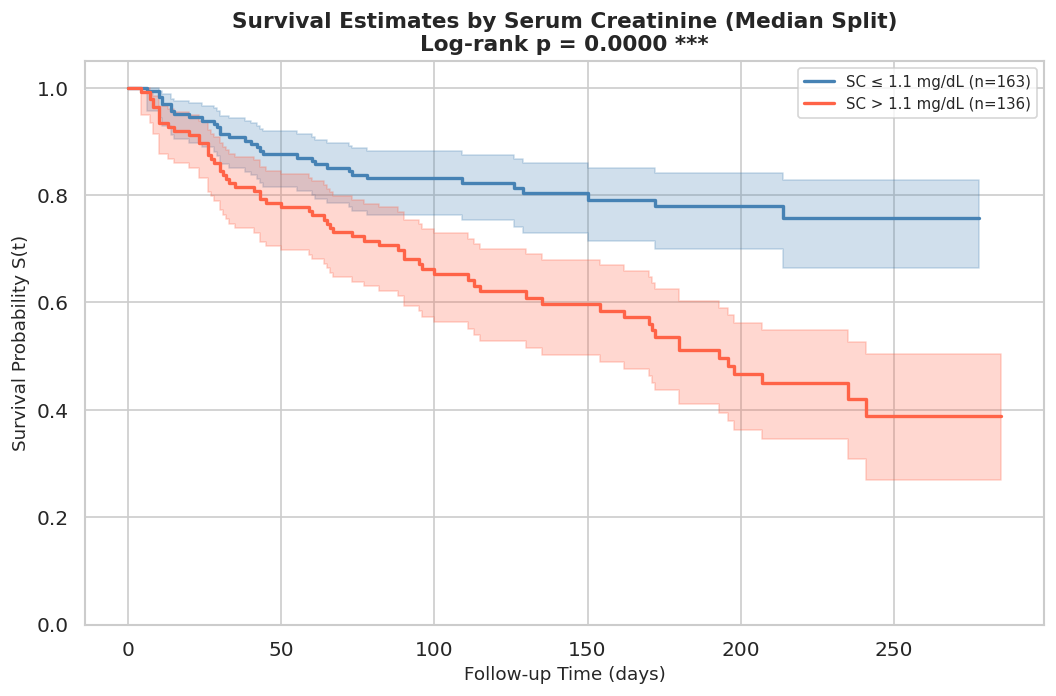

In [13]:
med_sc = df['serum_creatinine'].median()
df['sc_group'] = (df['serum_creatinine'] > med_sc).astype(int)

plot_km_by_feature(df, 'sc_group',
                   labels={0: f'SC ≤ {med_sc} mg/dL',
                            1: f'SC > {med_sc} mg/dL'},
                   title='Survival Estimates by Serum Creatinine (Median Split)',
                   colors=['steelblue', 'tomato']);

## 11 · KM by Age Group

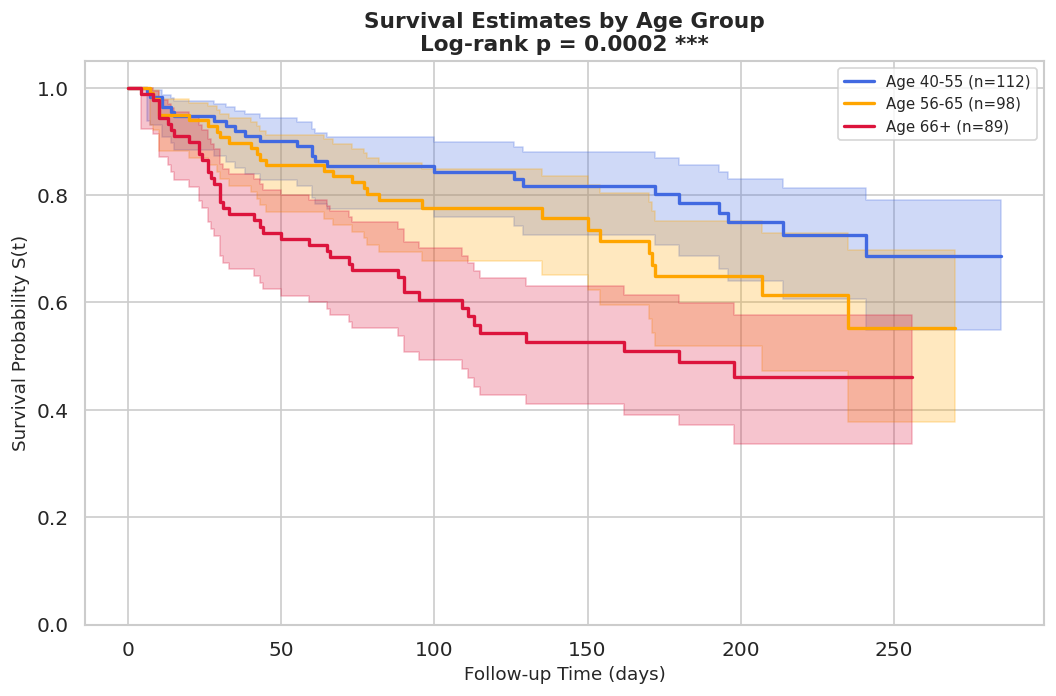

In [14]:
df['age_group'] = pd.cut(df['age'], bins=[39, 55, 65, 100],
                          labels=['40-55', '56-65', '66+'])
df['age_code'] = df['age_group'].cat.codes

plot_km_by_feature(df, 'age_code',
                   labels={0: 'Age 40-55', 1: 'Age 56-65', 2: 'Age 66+'},
                   title='Survival Estimates by Age Group',
                   colors=['royalblue', 'orange', 'crimson']);

## 12 · Summary Grid — All Binary Features

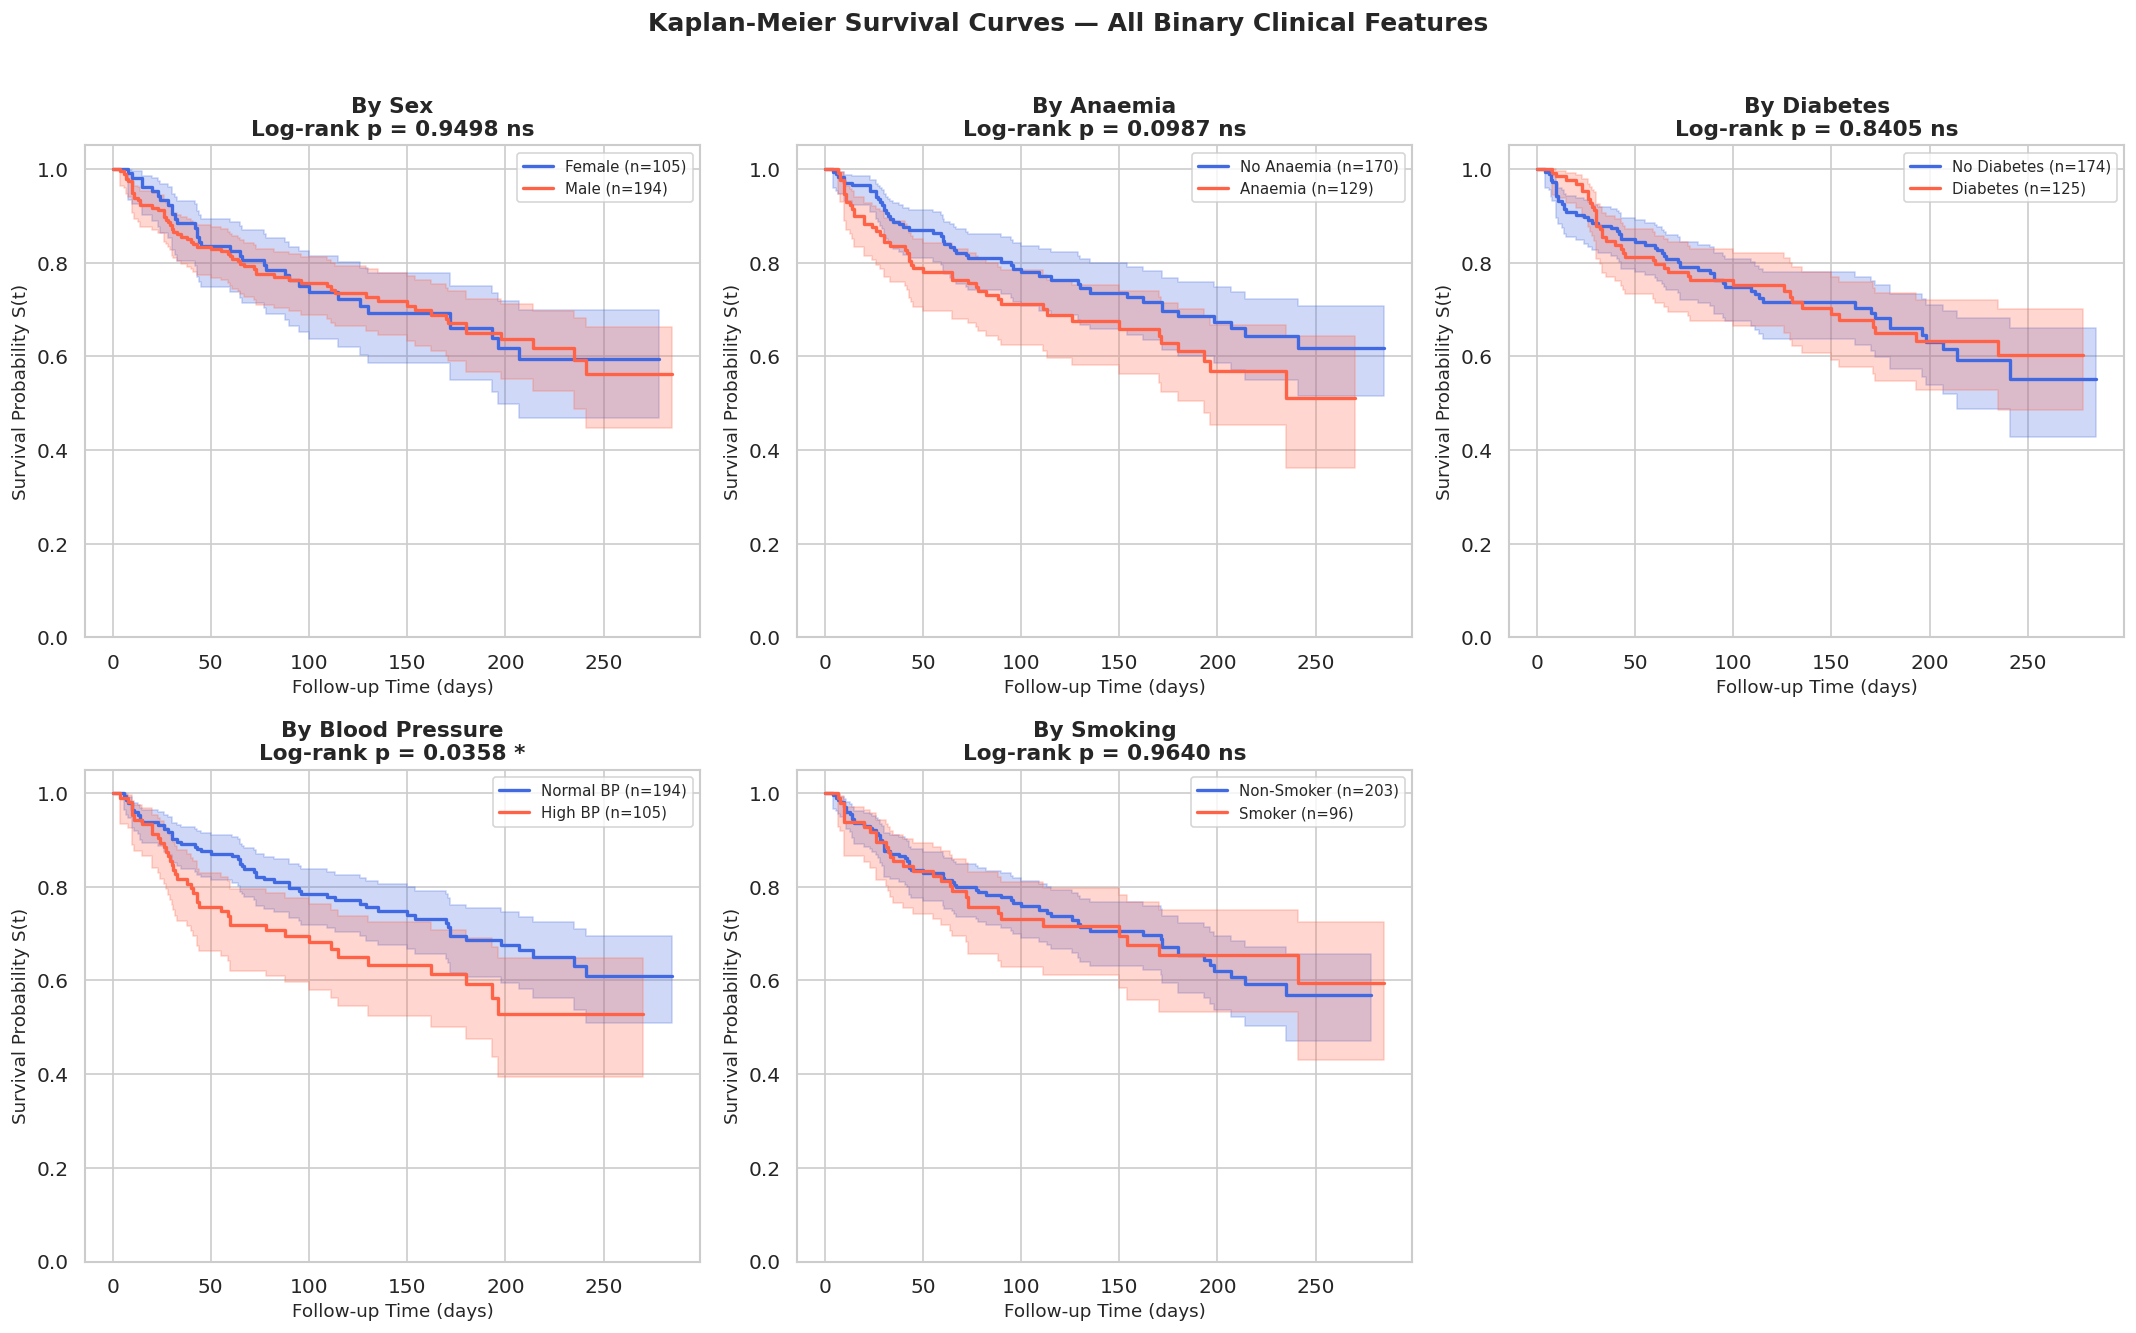

In [15]:
binary_features = [
    ('sex',                  {0: 'Female', 1: 'Male'},          'By Sex'),
    ('anaemia',              {0: 'No Anaemia', 1: 'Anaemia'},   'By Anaemia'),
    ('diabetes',             {0: 'No Diabetes', 1: 'Diabetes'}, 'By Diabetes'),
    ('high_blood_pressure',  {0: 'Normal BP', 1: 'High BP'},    'By Blood Pressure'),
    ('smoking',              {0: 'Non-Smoker', 1: 'Smoker'},    'By Smoking'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (feat, labs, title) in enumerate(binary_features):
    plot_km_by_feature(df, feat, labels=labs, title=title, ax=axes[i])

axes[-1].set_visible(False)
plt.suptitle('Kaplan-Meier Survival Curves — All Binary Clinical Features',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13 · Median Survival Summary Table

In [16]:
results = []
configs = [
    ('Overall',        None,   None,          None),
    ('Sex=Female',     'sex',  0,             None),
    ('Sex=Male',       'sex',  1,             None),
    ('No Anaemia',     'anaemia', 0,          None),
    ('Anaemia',        'anaemia', 1,          None),
    ('No Diabetes',    'diabetes', 0,         None),
    ('Diabetes',       'diabetes', 1,         None),
    ('Normal BP',      'high_blood_pressure', 0, None),
    ('High BP',        'high_blood_pressure', 1, None),
    ('Non-Smoker',     'smoking', 0,          None),
    ('Smoker',         'smoking', 1,          None),
]

for label, col, val, _ in configs:
    if col is None:
        mask = pd.Series([True] * len(df))
    else:
        mask = df[col] == val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'DEATH_EVENT'])
    results.append({
        'Group':  label,
        'n':      mask.sum(),
        'Events': df.loc[mask, 'DEATH_EVENT'].sum(),
        'Median Survival (days)': kmf.median_survival_time_,
        'S(100 days)': round(kmf.survival_function_at_times([100]).values[0], 3),
        'S(200 days)': round(kmf.survival_function_at_times([200]).values[0], 3),
    })

pd.DataFrame(results).set_index('Group')

,n,Events,Median Survival (days),S(100 days),S(200 days)
Group,,,,,
Overall,299,96,inf,0.750,0.631
Sex=Female,105,34,inf,0.737,0.618
Sex=Male,194,62,inf,0.756,0.638
No Anaemia,170,50,inf,0.779,0.674
Anaemia,129,46,inf,0.712,0.568
No Diabetes,174,56,inf,0.748,0.631
Diabetes,125,40,inf,0.752,0.633
Normal BP,194,57,inf,0.785,0.676
High BP,105,39,inf,0.682,0.529


## 14 · Log-Rank Test Summary

In [17]:
comparisons = [
    ('sex',                 {0: 'Female', 1: 'Male'}),
    ('anaemia',             {0: 'No Anaemia', 1: 'Anaemia'}),
    ('diabetes',            {0: 'No Diabetes', 1: 'Diabetes'}),
    ('high_blood_pressure', {0: 'Normal BP', 1: 'High BP'}),
    ('smoking',             {0: 'Non-Smoker', 1: 'Smoker'}),
    ('sc_group',            {0: 'SC Low', 1: 'SC High'}),
]

print(f'{"Feature":<25} {"p-value":>10}  Significant (α=0.05)?')
print('-' * 55)
for col, labs in comparisons:
    g0 = df[df[col] == 0]
    g1 = df[df[col] == 1]
    result = logrank_test(g0['time'], g1['time'],
                          event_observed_A=g0['DEATH_EVENT'],
                          event_observed_B=g1['DEATH_EVENT'])
    sig = '✔ YES ***' if result.p_value < 0.001 else \
          ('✔ YES **'  if result.p_value < 0.01  else \
          ('✔ YES *'   if result.p_value < 0.05  else '✘ NO'))
    print(f'{col:<25} {result.p_value:>10.4f}  {sig}')

Feature                      p-value  Significant (α=0.05)?
-------------------------------------------------------
sex                           0.9498  ✘ NO
anaemia                       0.0987  ✘ NO
diabetes                      0.8405  ✘ NO
high_blood_pressure           0.0358  ✔ YES *
smoking                       0.9640  ✘ NO
sc_group                      0.0000  ✔ YES ***
